# 04 Sentiment Model Training

Goal: fine-tune `distilroberta-base` on `takala/financial_phrasebank` for 3-class sentiment classification (`positive`, `negative`, `neutral`).

This notebook covers:
- loading the dataset from Hugging Face
- train / validation split
- tokenization with `AutoTokenizer`
- model fine-tuning with the `Trainer` API
- evaluation using accuracy, precision, recall, and F1
- confusion matrix visualization
- saving the trained model
- example predictions


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import torch

from datasets import DatasetDict, load_dataset
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

SEED = 42
BASE_MODEL = "distilroberta-base"
DATASET_NAME = "fhamborg/news_sentiment_newsmtsc"
OUTPUT_DIR = Path("./sentiment_distilroberta_financial_phrasebank")
MAX_TOKEN_LENGTH = 512

def set_seed(seed: int = 42) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")
print(f"Torch version: {torch.__version__}")

Using device: cuda
Torch version: 2.10.0+cu130


## 4.1 Load Dataset

The dataset stores sentiment labels either as strings or `ClassLabel` integers depending on configuration, so we standardize them before training.

In [2]:
# Load one of the standard Financial PhraseBank configurations.
# Other common options are: sentences_75agree, sentences_66agree, sentences_50agree.
raw_dataset = load_dataset(
    DATASET_NAME,
    trust_remote_code=True
)
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 8739
    })
    test: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 803
    })
    validation: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id'],
        num_rows: 343
    })
})

In [3]:
base_dataset = raw_dataset['train']
base_dataset.to_pandas().head()

,mention,polarity,from,to,sentence,id
0,Winner,0,0,6,Winner wrote that she had a 30-minute private ...,allsides_1000_401_25_Reality Leigh Winner_0_6
1,She,-1,0,3,She also recently referred to President Trump ...,allsides_1000_401_3_Reality Leigh Winner_0_3
2,President Trump,-1,30,45,She also recently referred to President Trump ...,allsides_1000_401_3_’ Trump_30_45
3,Hillary Clinton,-1,0,15,Hillary Clinton blamed the Democratic National...,allsides_1018_408_1_Hillary Clinton_2_17
4,Facebook,-1,58,66,Hillary Clinton blamed the Democratic National...,allsides_1018_408_1_Facebook_60_68


In [4]:
label_list = ["negative", "neutral", "positive"]
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for label, idx in label2id.items()}

def add_label_id(example):
    example["label_id"] = {-1: 0, 0: 1, 1: 2}[example['polarity']]
    example['label_text'] = id2label[example["label_id"]]
    return example

base_dataset = base_dataset.map(add_label_id)
label_counts = pd.Series(base_dataset["label_text"]).value_counts().reindex(label_list, fill_value=0)
print("Label distribution:")
display(label_counts.to_frame(name="count"))

Label distribution:


,count
negative,3316
neutral,3028
positive,2395


In [5]:
# Train-test split with stratification to maintain label distribution

indices = np.arange(len(base_dataset))
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=base_dataset["label_id"],
)

dataset = DatasetDict({
    "train": base_dataset.select(train_indices),
    "validation": base_dataset.select(val_indices),
})

print(dataset)
print("Train size:", len(dataset["train"]))
print("Validation size:", len(dataset["validation"]))

DatasetDict({
    train: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id', 'label_id', 'label_text'],
        num_rows: 6991
    })
    validation: Dataset({
        features: ['mention', 'polarity', 'from', 'to', 'sentence', 'id', 'label_id', 'label_text'],
        num_rows: 1748
    })
})
Train size: 6991
Validation size: 1748


## 4.2 Train

In [6]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_batch(batch):
    """Tokenize a batch of sentences with truncation for sequence classification."""
    return tokenizer(
        batch['sentence'],
        truncation=True,
        max_length=MAX_TOKEN_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label_id", "labels")
tokenized_dataset = tokenized_dataset.remove_columns(['mention', 'polarity', 'from', 'to', 'id', 'label_text'])
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized_dataset


DatasetDict({
    train: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 6991
    })
    validation: Dataset({
        features: ['sentence', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 1748
    })
})

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

def compute_metrics(eval_pred):
    """Compute classification metrics from model logits."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_60294/2357881151.py:46: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [8]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.780100,0.650865,0.726545,0.732806,0.726545,0.718689
2,0.585300,0.628585,0.728833,0.729629,0.728833,0.725820
3,0.488400,0.651803,0.732838,0.739801,0.732838,0.725273
4,0.418600,0.670123,0.733410,0.731956,0.733410,0.731874
5,0.367700,0.693899,0.734554,0.733591,0.734554,0.731704


TrainOutput(global_step=1095, training_loss=0.5280128026117473, metrics={'train_runtime': 95.3352, 'train_samples_per_second': 366.654, 'train_steps_per_second': 11.486, 'total_flos': 799864059913002.0, 'train_loss': 0.5280128026117473, 'epoch': 5.0})

## 4.3 Evaluation

In [9]:
eval_metrics = trainer.evaluate()
eval_metrics

{'eval_loss': 0.6701225638389587,
 'eval_accuracy': 0.7334096109839817,
 'eval_precision': 0.7319564100162864,
 'eval_recall': 0.7334096109839817,
 'eval_f1': 0.7318742784184662,
 'eval_runtime': 1.4384,
 'eval_samples_per_second': 1215.222,
 'eval_steps_per_second': 38.236,
 'epoch': 5.0}

In [10]:
pred_output = trainer.predict(tokenized_dataset["validation"])
val_logits = pred_output.predictions
val_labels = pred_output.label_ids
val_preds = np.argmax(val_logits, axis=-1)

report = classification_report(
    val_labels,
    val_preds,
    target_names=label_list,
    zero_division=0,
)
print(report)

              precision    recall  f1-score   support

    negative       0.74      0.78      0.76       663
     neutral       0.70      0.64      0.67       606
    positive       0.76      0.79      0.77       479

    accuracy                           0.73      1748
   macro avg       0.73      0.74      0.73      1748
weighted avg       0.73      0.73      0.73      1748



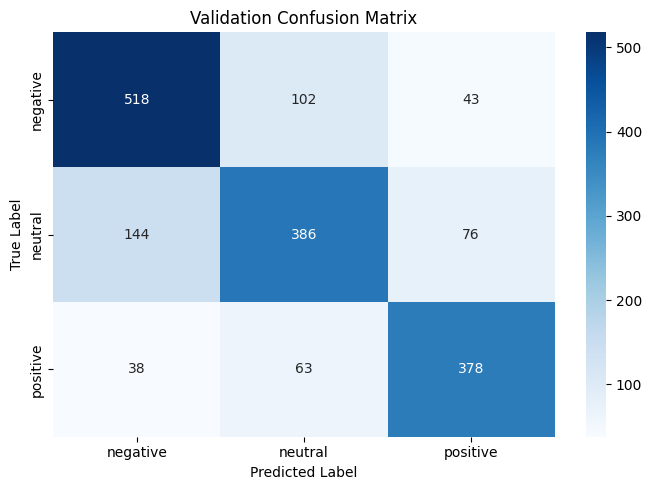

In [11]:
# Confusion Matrix

cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_list,
    yticklabels=label_list,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [12]:
# Save model

trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

print(f"Saved model to: {OUTPUT_DIR.resolve()}")

Saved model to: /home/threeg/code/zjy-nlp-2603/sentiment_distilroberta_financial_phrasebank


## 4.4 Apply Model to Article Summaries

In [13]:
summary_df = pd.read_parquet('024_labeled_cluster_data.parquet')
summary_df.head()

,date,title,summary,organization,industry,impact,technology,cluster,topic
0,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Bad Idea AI (BAD) is a cryptocurrency with a c...,Bad Idea AI,Cryptocurrency,0,AI,-1,
1,2024-07-01,This AI video of gymnastics might be the freak...,AI-generated videos of gymnastics and wrestlin...,Luma Dream Machine,Media and Entertainment,-2,AI-generated video,-1,
2,2024-09-22,"If using AI feels like a chore, try this - Boi...",1minAI offers a lifetime subscription for $39....,1minAI,Software,1,"GPT-4, Gemini Pro, Claude",1292,AI tools and services with lifetime or discoun...
3,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,"China's AI Foundation Model, developed by Baid...",Baidu,Automotive,2,"deep learning, big data, cloud computing",-1,
4,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia are collaborating to empo...,Microsoft and Nvidia,Technology,1,Windows AI Studio and TensorRT-LLM,-1,


In [15]:
clf = pipeline(
    "text-classification",
    model='sentiment_distilroberta_financial_phrasebank',
    tokenizer='sentiment_distilroberta_financial_phrasebank',
)

preds = clf(
    summary_df["summary"].tolist(),
    batch_size=32,
    truncation=True,
    max_length=MAX_TOKEN_LENGTH
)

summary_df["sentiment"] = [x["label"] for x in preds]
summary_df["score"] = [x["score"] for x in preds]
summary_df.head()

Device set to use cuda:0


,date,title,summary,organization,industry,impact,technology,cluster,topic,sentiment,score
0,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...",Bad Idea AI (BAD) is a cryptocurrency with a c...,Bad Idea AI,Cryptocurrency,0,AI,-1,,neutral,0.497150
1,2024-07-01,This AI video of gymnastics might be the freak...,AI-generated videos of gymnastics and wrestlin...,Luma Dream Machine,Media and Entertainment,-2,AI-generated video,-1,,negative,0.885189
2,2024-09-22,"If using AI feels like a chore, try this - Boi...",1minAI offers a lifetime subscription for $39....,1minAI,Software,1,"GPT-4, Gemini Pro, Claude",1292,AI tools and services with lifetime or discoun...,positive,0.878731
3,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,"China's AI Foundation Model, developed by Baid...",Baidu,Automotive,2,"deep learning, big data, cloud computing",-1,,positive,0.964069
4,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia are collaborating to empo...,Microsoft and Nvidia,Technology,1,Windows AI Studio and TensorRT-LLM,-1,,positive,0.971830


In [16]:
summary_df.to_parquet('040_sentiment.parquet')